# Straight Line, Plane and Hyperplane

## Quick revision notes
These ideas help ML models draw a boundary between groups, for example `spam` and `not spam`.

## 1. A straight line in 2D
A straight line is written as:

$$y = mx + c$$

- $m$ is the **slope**: how steep the line is.
- $c$ is the **intercept**: where the line touches the y-axis.

**Example:** $y = 2x + 1$ means: move right by 1, then move up by 2. The line starts at height 1.

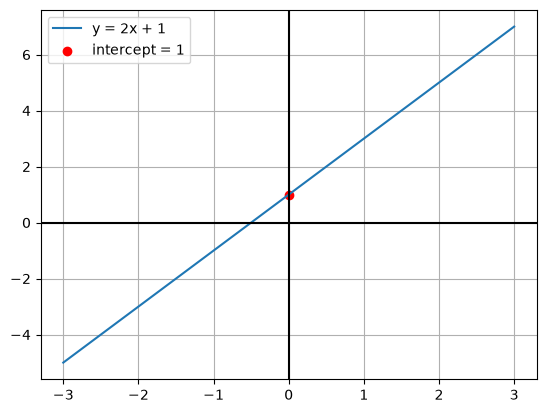

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = 2 * x + 1
plt.plot(x, y, label='y = 2x + 1')
plt.scatter([0], [1], color='red', label='intercept = 1')
plt.axhline(0, color='black'); plt.axvline(0, color='black')
plt.grid(); plt.legend(); plt.show()

**What the diagram shows:** the red dot is the starting height, and the blue line goes up as it moves right. This is what slope means.

## 2. Another way to write a line
A line can also be written as:

$$ax + by + c = 0$$

**Example:** $2x - y + 3 = 0$ becomes $y = 2x + 3$. It is the same line written in another way.

In [2]:
a, b, c = 2, -1, 3
slope = -a / b
intercept = -c / b
print('Slope:', slope)
print('Y-intercept:', intercept)

Slope: 2.0
Y-intercept: 3.0


**What the code does:** it changes the second form into slope and intercept values, so the line is easier to understand and draw.

## 3. ML version of the same idea
In machine learning, we often write the boundary as:

$$w^T x + b = 0$$

- $x$ = input values (features).
- $w$ = weights; they say how important each feature is.
- $b$ = bias/intercept; it moves the boundary.

**Example:** put $w = [2, -1]$, $x = [1, 5]$, and $b = 3$ into the equation. The answer is 0, so the point sits exactly on the line.

In [6]:
w = np.array([2, -1])
x_point = np.array([1, 5])
b = 3
print('Boundary value:', w @ x_point + b)

Boundary value: 0


**What the code does:** it puts one point into the boundary equation. A result of 0 means “the point is on the line.”

## 4. Line, plane, and hyperplane

| Number of features | Boundary name | Simple picture |
|---|---|---|
| 2 features | Line | A flat line on paper |
| 3 features | Plane | A flat sheet in space |
| More than 3 features | Hyperplane | A boundary we cannot easily draw |

The equation stays similar:

$$w^T x + b = 0$$

Only the number of features changes.

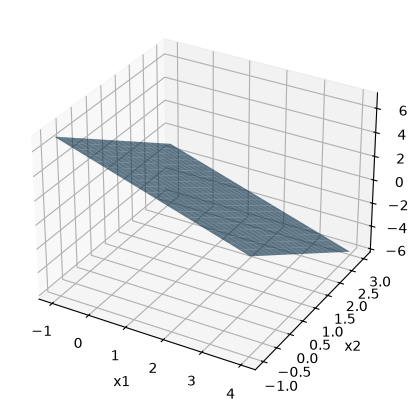

In [4]:
from mpl_toolkits.mplot3d import Axes3D
grid_x, grid_y = np.meshgrid(np.linspace(-1, 4, 20), np.linspace(-1, 3, 20))
grid_z = 4 - grid_x - 2 * grid_y  # x + 2y + z - 4 = 0
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, alpha=0.65)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
plt.show()

**What the diagram shows:** with three features, the boundary is no longer a line. It becomes a flat sheet called a plane.

## 5. Normal vector and distance
$w$ is called the **normal vector**. It points straight out from the line or plane at a right angle.

For a point `s`, the shortest distance to a boundary is:

$$distance = |w^T s + b| / ||w||$$

The bars $| |$ make distance positive. Without them, the sign tells which side of the boundary the point is on.

In [5]:
def signed_distance(point, weights, bias):
    return (weights @ point + bias) / np.linalg.norm(weights)

weights = np.array([3, 4])
point = np.array([4, 2])
answer = signed_distance(point, weights, -10)
print('Signed distance:', answer)
print('Actual distance:', abs(answer))

Signed distance: 2.0
Actual distance: 2.0


**What the code does:** it finds how far the point is from the boundary. Positive and negative answers mean opposite sides; the actual distance is always positive.

## Why this matters in ML
A classifier checks the sign of:

$$w^T x + b$$

- positive → one group
- negative → the other group
- zero → exactly on the boundary

**Memory trick:** 2 features = line, 3 features = plane, many features = hyperplane.